In [148]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

import healpy as hp

import astropy.units as u


In [149]:
def set_plotting_defaults():
    # default figure size
    mpl.rcParams["figure.figsize"] = [7, 5]

    # Set default font size
    mpl.rcParams['font.size'] = 12
    return

In [150]:
data_2mass = np.load("./2mass/2mass-table.npz")
df_2mass = pd.DataFrame(np.array([data_2mass["ra"], data_2mass["dec"], data_2mass["z"]]).T, columns=["ra", "dec", "z"])
df_2mass = df_2mass[df_2mass["z"] > 0.01]

In [151]:
data_6df = np.load("./6df/6df-clean.npz")
df_6df = pd.DataFrame(np.array([data_6df["ra"], data_6df["dec"], data_6df["z"]]).T, columns=["ra", "dec", "z"])
df_6df = df_6df[df_6df["z"] > 0.01]

In [152]:
gal_south = np.load("./sdss/galaxy_south_reduced.npz")
gal_north = np.load("./sdss/galaxy_north_reduced.npz")
gal_north1 = np.array([gal_north["ra"], gal_north["dec"], gal_north["z"]])
gal_south1 = np.array([gal_south["ra"], gal_south["dec"], gal_south["z"]])
gal = np.hstack((gal_north1, gal_south1)).T
df_sdss = pd.DataFrame(gal, columns=["ra", "dec", "z"])
df_sdss = df_sdss[df_sdss["z"] > 0.01]

In [153]:
nside = 128
npix = hp.nside2npix(nside)

In [ ]:
from astropy.cosmology import LambdaCDM
from scipy.interpolate import interp1d

cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

redshifts = np.linspace(0, 1, 100)
distances = cosmo.comoving_distance(redshifts).to_value(u.Mpc)

z_d = interp1d(redshifts, distances, kind='linear')
d_z = interp1d(distances, redshifts, kind='linear')

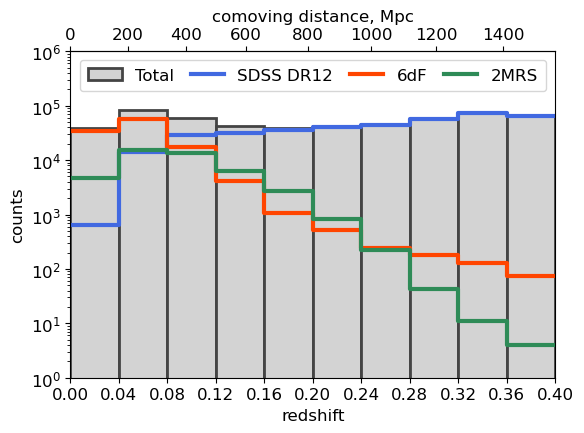

In [188]:
set_plotting_defaults()
fig, ax = plt.subplots(1, figsize=(6, 4.5))
bw = 0.04
br = [0.00, 0.4]
total = np.hstack((df_2mass["z"], df_6df["z"], df_sdss["z"]))

ax.hist(total, bins=int(br[1]/bw), range=br,
         linewidth=2, facecolor='lightgray', edgecolor='#444', label='Total')

sns.histplot(df_sdss["z"], ax=ax,
             binwidth=bw, binrange=br,
             color='royalblue', element='step', linewidth=3, fill=False,
             label="SDSS DR12")
sns.histplot(df_6df["z"], ax=ax,
             binwidth=bw, binrange=br,
             color='orangered', element='step', linewidth=3, fill=False,
             label="6dF")
sns.histplot(df_2mass["z"], ax=ax,
             binwidth=bw, binrange=br,
             color='seagreen', element='step', linewidth=3, fill=False,
             label="2MRS")

ax.set_xlabel("redshift")
ax.set_xlim(br)
ax.set_xticks(np.arange(br[0], br[1]*1.01, bw))

ax.set_ylabel("counts")
ax.set_yscale('log')
ax.set_ylim(1.0, 1e6)

ax2 = ax.secondary_xaxis('top', functions=(z_d, d_z))
ax2.set_xlabel("comoving distance, Mpc")

ax.legend(loc='upper center', ncol=4, columnspacing=1.0, borderpad=0.5)
plt.tight_layout()

# plt.savefig("rsh_dist.pdf")
plt.show()